<a href="https://colab.research.google.com/github/varshith2589/machine-leanring/blob/main/salary_predction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("salary_prediction_data.csv")
df.head()

,Education,Experience,Location,Job_Title,Age,Gender,Salary
0,High School,8,Urban,Manager,63,Male,84620.053665
1,PhD,11,Suburban,Director,59,Male,142591.255894
2,Bachelor,28,Suburban,Manager,61,Female,97800.255404
3,High School,29,Rural,Director,45,Male,96834.671282
4,PhD,25,Urban,Analyst,26,Female,132157.786175


In [3]:
df.isnull().sum()
df.dropna()

,Education,Experience,Location,Job_Title,Age,Gender,Salary
0,High School,8,Urban,Manager,63,Male,84620.053665
1,PhD,11,Suburban,Director,59,Male,142591.255894
2,Bachelor,28,Suburban,Manager,61,Female,97800.255404
3,High School,29,Rural,Director,45,Male,96834.671282
4,PhD,25,Urban,Analyst,26,Female,132157.786175
...,...,...,...,...,...,...,...
995,High School,8,Suburban,Analyst,25,Female,64683.389864
996,High School,24,Urban,Engineer,30,Female,74468.205020
997,Master,18,Rural,Analyst,44,Male,98207.026024
998,Bachelor,27,Suburban,Director,31,Female,108544.922720


In [4]:
x=df.drop('Experience', axis=1)
y=df['Salary']

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
y = df['Salary']

x = df.drop(['Experience', 'Salary'], axis=1)

categorical_cols = ['Education', 'Location', 'Job_Title', 'Gender']

x_encoded = pd.get_dummies(x, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, random_state=42) # Using a random_state for reproducibility

lr=LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [14]:
from sklearn.metrics import r2_score, mean_squared_error

# Predict using Linear Regression
lr_pred = lr.predict(X_test)

# Calculate metrics for Linear Regression
lr_r2 = r2_score(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)

print(f"Linear Regression R2 Score: {lr_r2}")
print(f"Linear Regression MSE: {lr_mse}")

# Quick comparison with your existing Decision Tree score
print(f"Decision Tree R2 Score: {dt_r2_score}") # dt_r2_score was defined in your previous cell

Linear Regression R2 Score: 0.7587202722630848
Linear Regression MSE: 197011304.99821416
Decision Tree R2 Score: 0.7484756920331161


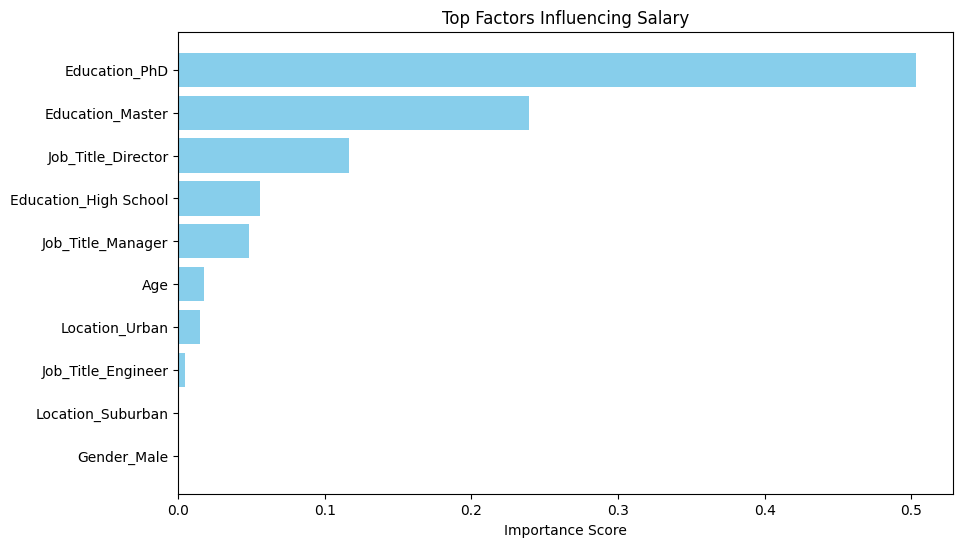

In [16]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
import pandas as pd

# Re-define and fit the DecisionTreeRegressor since the original cell was deleted
# Using the X_train and y_train that were prepared in previous steps
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42) # Using random_state for reproducibility
dt_model.fit(X_train, y_train)

# Get feature names from the encoded dataframe
features = X_train.columns

# Now calculate importances from the correctly fitted DecisionTreeRegressor
importances = dt_model.feature_importances_

# Create a DataFrame for visualization
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_df['Feature'], feature_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top Factors Influencing Salary')
plt.gca().invert_yaxis()
plt.show()

In [21]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
print(f"Random forest: {rf_r2}")

Random forest: 0.7569287271468175


In [25]:
def predict_salary(age, education, location, job_title, gender):
    input_data = {'Age': [age]}

    all_columns = X_train.columns
    for col in all_columns:
        if col != 'Age':
            input_data[col] = [0]

    if f"Education_{education}" in input_data: input_data[f"Education_{education}"] = [1]
    if f"Location_{location}" in input_data: input_data[f"Location_{location}"] = [1]
    if f"Job_Title_{job_title}" in input_data: input_data[f"Job_Title_{job_title}"] = [1]
    if f"Gender_{gender}" in input_data: input_data[f"Gender_{gender}"] = [1]

    input_df = pd.DataFrame(input_data)
    prediction = rf_model.predict(input_df)
    return prediction[0]

example_salary = predict_salary(35, 'PhD', 'Urban', 'Director', 'Male')
print(f"Predicted Salary for a 35yr old PhD Director in Urban area: ${example_salary:,.2f}")

Predicted Salary for a 35yr old PhD Director in Urban area: $150,658.97


In [24]:

salary1 = predict_salary(age=25, education='Bachelor', location='Rural', job_title='Analyst', gender='Female')
print(f"Predicted Salary for a 25yr old Bachelor Analyst in Rural area (Female): ${salary1:,.2f}")

salary2 = predict_salary(age=50, education='Master', location='Urban', job_title='Manager', gender='Male')
print(f"Predicted Salary for a 50yr old Master Manager in Urban area (Male): ${salary2:,.2f}")

salary3 = predict_salary(age=40, education='PhD', location='Suburban', job_title='Engineer', gender='Female')
print(f"Predicted Salary for a 40yr old PhD Engineer in Suburban area (Female): ${salary3:,.2f}")

salary4 = predict_salary(age=22, education='High School', location='Rural', job_title='Analyst', gender='Male')
print(f"Predicted Salary for a 22yr old High School Analyst in Rural area (Male): ${salary4:,.2f}")

Predicted Salary for a 25yr old Bachelor Analyst in Rural area (Female): $83,749.10
Predicted Salary for a 50yr old Master Manager in Urban area (Male): $122,984.98
Predicted Salary for a 40yr old PhD Engineer in Suburban area (Female): $127,203.75
Predicted Salary for a 22yr old High School Analyst in Rural area (Male): $67,762.16
